In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Adversarial Losses Beyond GANs

The chapter has so far used adversarial objectives to train stand-alone samplers. that section analyzed the original objective, that section compared its alternatives, that section and that section studied its landscape and dynamics, and that section applied the resulting recipe to images. Current image, audio, and video generators are often trained instead by regression against closed-form targets, as developed in that section. Adversarial losses nevertheless remain in one-step image generators, the tokenizers used by latent-space models, and neural vocoders. This section explains why these applications retain a learned comparison. It concludes by separating the adversarial objective from the simultaneous two-player optimization used to estimate it.

The common mechanism is a mismatch between a pointwise regression loss and a model that lacks the capacity or information to represent every valid output. We first demonstrate this mismatch on a small problem whose regression and adversarial solutions can be compared directly. We then examine its consequences for distillation, tokenizers, audio, and video. The final sections compare three approaches to adversarial instability and show how the density-ratio identity of that section can be used inside a likelihood model without training a separate discriminator.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import jax
from jax import numpy as jnp
from flax import nnx
import numpy as np
import optax

## The Capacity Argument

Many generation problems are conditional predictions. A super-resolution network receives a low-resolution image and must produce a high-resolution one; a vocoder receives a spectrogram and must produce a waveform; a one-step distillation student receives a noise vector and must produce, in a single forward pass, the image its teacher builds over hundreds of evaluations. The default loss for a prediction is the pointwise squared error, and its minimizer is a classical identity. For any predictor $f$ and the conditional mean $\mu(x) = E[y \mid x]$, adding and subtracting $\mu$ inside the square and noting that the cross term vanishes conditionally on $x$ gives

$$
E\big[(y - f(x))^2\big]
\;=\;
E\big[(y - \mu(x))^2\big] \;+\; E\big[(\mu(x) - f(x))^2\big].
$$

The first term does not depend on $f$, and the second is the squared distance between $f(x)$ and the conditional mean. Minimizing squared error over all functions therefore gives $f = \mu$. A capacity-limited model approximates this conditional mean as closely as its function class permits. When $p(y \mid x)$ concentrates around a single answer, the conditional mean represents that answer well. When several distinct answers are possible, however, the mean combines them and need not itself be valid. For example, many sharp images may downsample to the same blurry thumbnail, while their pixelwise mean is not sharp under any of the original interpretations.

An adversarial loss evaluates a prediction differently. The optimal critic of that section scores a sample by the log density ratio the equation. It can therefore distinguish predictions in regions of low data density without measuring their pointwise distance to every valid answer. The two objectives behave similarly when $p(y \mid x)$ concentrates on one answer that the model can represent. With several incompatible answers, squared error favors their mean, whereas the critic favors predictions that remain within the data distribution.

The smallest problem exhibiting the split has one input, one output, and two answers. Draw $x$ uniformly from $[-1, 1]$ and set

$$
y \;=\; x + m + 0.05\,\epsilon,
\qquad
m \in \{-1, +1\} \textrm{ with probability } \tfrac12 \textrm{ each},
\quad \epsilon \sim \mathcal{N}(0, 1),
$$

with the mode $m$ drawn independently of $x$. The data form two parallel bands, $y = x \pm 1$, forty noise widths apart. The conditional mean is $\mu(x) = x$, a line through the empty corridor between them. Both students are the same deterministic network, a small two-hidden-layer perceptron mapping $x$ to a single $\hat y$, so neither can represent two answers for one input; the capacity limit is built in. The first student trains on the squared error. The second trains as the generator of the log-loss game against a critic that scores $(x, y)$ pairs, using the non-saturating weight of the equation; its prediction enters the game carrying the same observation noise as the data, so the two distributions the critic compares differ in structure rather than in smoothness.

In [2]:
class Student(nnx.Module):
    def __init__(self, rngs):
        self.h1 = nnx.Linear(1, 32, rngs=rngs)
        self.h2 = nnx.Linear(32, 32, rngs=rngs)
        self.out = nnx.Linear(32, 1, rngs=rngs)

    def __call__(self, x):
        return self.out(nnx.tanh(self.h2(nnx.tanh(self.h1(x)))))

class Critic(nnx.Module):
    def __init__(self, rngs):
        self.h1 = nnx.Linear(2, 32, rngs=rngs)
        self.h2 = nnx.Linear(32, 32, rngs=rngs)
        self.out = nnx.Linear(32, 1, rngs=rngs)

    def __call__(self, xy):
        h = nnx.leaky_relu(self.h1(xy), 0.2)
        return self.out(nnx.leaky_relu(self.h2(h), 0.2))

rng = np.random.default_rng(0)
n = 1024
x = jnp.asarray(rng.uniform(-1, 1, (n, 1)))
m = jnp.asarray(rng.integers(0, 2, (n, 1)) * 2.0 - 1.0)
y = x + m + 0.05 * jnp.asarray(rng.standard_normal((n, 1)))

f_mse = Student(nnx.Rngs(1))
opt = nnx.Optimizer(f_mse, optax.adam(0.01), wrt=nnx.Param)

@nnx.jit
def step_mse(f, opt, xb, yb):
    loss, grads = nnx.value_and_grad(
        lambda f_: ((f_(xb) - yb) ** 2).mean())(f)
    opt.update(f, grads)
    return loss

for _ in range(2000):
    idx = jnp.asarray(rng.integers(0, n, 128))
    step_mse(f_mse, opt, x[idx], y[idx])

softplus = jax.nn.softplus
f_adv = Student(nnx.Rngs(1))
critic = Critic(nnx.Rngs(2))
opt_G = nnx.Optimizer(f_adv, optax.adam(1e-3), wrt=nnx.Param)
opt_D = nnx.Optimizer(critic, optax.adam(2e-3), wrt=nnx.Param)

@nnx.jit
def step_D(f, D, opt_D, xb, yb, eps):
    fake = jnp.concatenate([xb, f(xb) + 0.05 * eps], 1)
    real = jnp.concatenate([xb, yb], 1)
    def loss_fn(D_):
        return (softplus(-D_(real)) + softplus(D_(fake))).mean()
    loss, grads = nnx.value_and_grad(loss_fn)(D)
    opt_D.update(D, grads)
    return loss

@nnx.jit
def step_G(f, D, opt_G, xb, eps):
    def loss_fn(f_):
        fake = jnp.concatenate([xb, f_(xb) + 0.05 * eps], 1)
        return softplus(-D(fake)).mean()
    loss, grads = nnx.value_and_grad(loss_fn)(f)
    opt_G.update(f, grads)
    return loss

for _ in range(8000):
    idx = jnp.asarray(rng.integers(0, n, 128))
    eps1 = jnp.asarray(rng.standard_normal((128, 1)))
    eps2 = jnp.asarray(rng.standard_normal((128, 1)))
    step_D(f_adv, critic, opt_D, x[idx], y[idx], eps1)
    step_G(f_adv, critic, opt_G, x[idx], eps2)

Two numbers summarize each student: the mean distance from its curve to the nearest of the two mode lines, and the mean distance to the conditional mean line $y = x$.

In [3]:
xs = jnp.linspace(-1, 1, 201).reshape(-1, 1)
curves = {'MSE student': f_mse(xs), 'adversarial student': f_adv(xs)}
for name, f in curves.items():
    to_mode = jnp.minimum(jnp.abs(f - xs - 1), jnp.abs(f - xs + 1)).mean()
    to_mean = jnp.abs(f - xs).mean()
    print(f'{name}: mean distance {to_mode:.2f} to the nearest mode, '
          f'{to_mean:.2f} to the conditional mean')
x_np, y_np, xs_np = np.asarray(x), np.asarray(y), np.asarray(xs)
curves_np = {k: np.asarray(v) for k, v in curves.items()}

MSE student: mean distance 0.90 to the nearest mode, 0.10 to the conditional mean
adversarial student: mean distance 0.02 to the nearest mode, 0.98 to the conditional mean


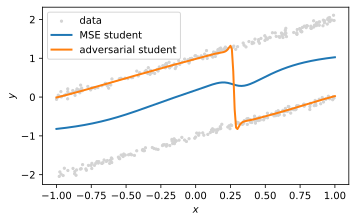

In [4]:
d2l.set_figsize((5.5, 3.2))
d2l.plt.scatter(x_np[:400], y_np[:400], s=5, c='lightgray', label='data')
for name, f in curves_np.items():
    d2l.plt.plot(xs_np, f, lw=2, label=name)
d2l.plt.xlabel('$x$'), d2l.plt.ylabel('$y$')
d2l.plt.legend();

In the displayed runs for both frameworks, the two students behave consistently. As predicted by the equation, the squared-error student's curve follows the conditional mean $y = x$ through the empty region between the bands. Its mean distance from the nearest mode is almost one unit, and the curve rarely passes near a data point. The adversarial student's curve lies on one of the two bands for nearly all inputs. In each displayed run, its mean distance from the nearest mode is only a few hundredths; most of the remaining error occurs in narrow intervals where the curve crosses between bands.

The selected band varies between runs. A curve may follow one band across the full input range, or follow different bands on separate intervals and cross between them, as in the displayed run. Because $m$ is independent of $x$, this switching introduces a dependence absent from the data distribution. Its location is determined by the continuity of the student and by optimization. Any continuous function that changes bands must pass through the empty region, but adversarial training limits this passage to a narrow interval. Squared-error training instead places predictions throughout that region.

The adversarial loss does not recover the full conditional distribution in this example. A deterministic student produces only one answer per input, so following one band leaves the other unrepresented. The critic influences the location of the student's graph but cannot add outputs to its hypothesis class. Models requiring conditional diversity must therefore include a latent input or retain a multi-step sampling process. They must also address the mode-coverage problem analyzed in that section.

At image scale, the two alternatives become the many sharp textures compatible with one prompt or low-resolution input. The SDXL-Lightning report finds that whole-image FID differs little across recent few-step text-to-image distillation methods, whereas patch-level FID shows larger differences [@Lin.Wang.Yang.2024]. Patch-level FID is more sensitive to local texture than to global layout. Conditioning determines much of the global arrangement, leaving greater ambiguity in high-frequency details, where the averaging effect in the equation is strongest. The adversarial term primarily improves these local details.

## Distillation

Diffusion and flow models, previewed here and developed in that section, generate samples by repeatedly evaluating a learned denoiser, often requiring dozens or hundreds of network evaluations [@ho2020denoising; @Lipman.Chen.BenHamu.ea.2022]. Distillation trains a student to approximate the resulting distribution in one to four evaluations. A one-step student must represent the output of a long iterative computation in a single forward pass. Pointwise regression on teacher outputs or scores can therefore exhibit the averaging behavior derived above.

Adversarial diffusion distillation makes this trade-off explicit [@Sauer.Lorenz.Blattmann.ea.2023]. ADD trains a one-step student with a score-distillation regression toward a frozen teacher and an adversarial loss against real images. Its critic uses frozen DINOv2 features with small trainable heads. In the reported one-step ablation, with other settings held fixed, distillation alone gives FID 315.6, the adversarial loss alone gives 20.8, and the two together give 20.6. In this setting, the regression target produces averages that score poorly, while the adversarial term supplies nearly all of the measured sample fidelity. The teacher still provides guidance but does not by itself yield a useful one-step sampler.

Later systems use the adversarial term for different reasons. DMD2 adds an adversarial loss to train on real data rather than only sharpen teacher outputs, allowing its ImageNet-64 student to reach FID 1.28, below its teacher [@Yin.Gharbi.Park.ea.2024]. LADD reuses the teacher diffusion model as the discriminator backbone and finds synthetic teacher samples effective enough to remove the distillation loss entirely, leaving only the adversarial objective [@Sauer.Boesel.Dockhorn.ea.2024]. The approach is also used in deployed models. The FLUX.1-schnell model card states that its twelve-billion-parameter rectified-flow transformer was trained by latent adversarial diffusion distillation to generate in one to four steps [@BlackForestLabs.2024].

Few-step generation does not require an adversarial term. MeanFlow trains a one-evaluation generator from scratch, without a teacher, distillation, or discriminator, and reports FID 3.43 on ImageNet-256 [@Geng.Deng.Bai.ea.2025]. Continuous-time consistency models report FID 1.88 on ImageNet-512 using two evaluations and no adversarial loss [@Lu.Song.2025]. Both methods replace the critic with a regression target designed to remain informative at low step counts. Thus adversarial training is one solution to the capacity constraints of few-step generation, but it is not the only one.

## Tokenizers, Audio, Video

Latent-space generative models use an autoencoder, and many influential autoencoders include an adversarial loss. VQGAN combined reconstruction and perceptual losses with a patch-based discriminator [@Esser.Rombach.Ommer.2021]; the Stable Diffusion autoencoder retained this combination because the patch critic reduces the blurring associated with pixelwise losses and favors reconstructions on the image manifold [@Rombach.Blattmann.Lorenz.ea.2022]. This is the capacity argument applied to local patches: a compressed code does not determine the exact texture at every location, so squared error averages over plausible textures.

The ViTok study found that adversarial fine-tuning of the decoder improved reconstruction FID by roughly a factor of three in its reference configuration, although downstream generation FID changed much less [@Hansen-Estruch.Yan.Chung.ea.2025]. A later five-billion-parameter version removed both the adversarial and LPIPS losses and used a fixed perceptual loss based on self-supervised DINOv3 features, because the adversarial loss prevented stable scaling [@Hansen-Estruch.Chen.Ramanujan.ea.2026]. This result illustrates the optimization constraint analyzed in that section: when fixed features provide a sufficiently informative discrepancy, they can replace a learned critic.

Adversarial training remains a major approach to neural vocoding and is common in deployed low-latency systems. The discriminator ensembles introduced by HiFi-GAN continue in the BigVGAN family [@Kong.Kim.Bae.2020; @Lee.Ping.Ginsburg.ea.2023]. RAF applies the relativistic pairing loss of that section to waveforms; a pairing-trained BigVGAN-base outperforms an LSGAN-trained BigVGAN while using twelve percent as many parameters [@Lee.Choi.2026]. Diffusion and flow-matching vocoders provide non-adversarial alternatives. For example, WaveFM uses flow matching followed by consistency distillation to obtain single-step synthesis [@Luo.Miao.Duan.2025]. The capacity argument suggests why adversarial losses remain useful for audio: perceived quality depends strongly on phase and fine spectral structure, which pointwise conditional means can average away. Whether fixed perceptual features can replace the critic for audio, as DINO-family features have for images, remains unresolved.

A recent real-time video generator uses the same mechanism. Adversarial post-training fine-tunes the generator against real data, with a zero-centered gradient penalty in the family of that section, and produces two seconds of $1280 \times 720$ video at 24 frames per second in a single forward evaluation [@Lin.Xia.Ren.ea.2025].

## Three Responses to Adversarial Instability

Each application above inherits the failure modes analyzed earlier in the chapter, and ViTok-v2 shows that they can prevent stable scaling. Existing methods address three possible sources of instability: the gradient dynamics, the flexibility of the critic, or the two-player game itself. the figure compares representative methods and their costs.

![Three responses to unstable adversarial training, corresponding to different sources of instability: regularize the dynamics of the game, constrain the critic, or replace the game with a fixed discrepancy or regression objective. The first retains a minimax loop and a penalty weight; the second inherits the biases of its fixed features; the third may use discrepancies that weaken in high dimensions or require multi-step sampling. Adversarial losses can reappear when non-adversarial models are distilled to a few steps.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-gan-exits.svg)

The first response regularizes the gradient vector field. Support separation can eliminate the generator gradient [@Arjovsky.Bottou.2017]; zero-centered penalties restore local convergence under the conditions derived in that section [@Mescheder.Geiger.Nowozin.2018]. The pairing objective of that section changes the loss landscape [@Sun.Fang.Schwing.2020], and R3GAN combines pairing with gradient penalties [@Huang.Gokaslan.Kuleshov.ea.2024]. This approach retains the two-player optimization and requires a penalty weight tuned to the dataset.

The second response constrains the critic to reduce its co-adaptation with the generator. Spectral normalization bounds the critic's Lipschitz constant by construction and removes a regularization coefficient [@Miyato.Kataoka.Koyama.ea.2018]. Frozen critic features eliminate feature co-adaptation altogether. Projected GAN discriminates in the feature pyramid of a frozen pretrained classifier and reports reaching previous best FID values up to forty times faster [@Sauer.Chitta.Muller.ea.2021]. StyleGAN-T retains this construction but uses self-supervised features to reduce overlap with the evaluation network [@Sauer.Karras.Laine.ea.2023]. ADD uses a related DINOv2-based critic for distillation.

A critic can also overfit by memorizing a small training set. Applying the same differentiable augmentations to real and generated samples reduces this form of overfitting [@Zhao.Liu.Lin.ea.2020]; StyleGAN2-ADA adjusts the augmentation strength during training [@Karras.Aittala.Hellsten.ea.2020]. Frozen features introduce a different limitation: the critic inherits their biases and blind spots. Evaluation should therefore avoid feature extractors closely related to those used by the critic, as discussed in that section.

The third response removes the game. Generative moment matching networks minimize the fixed-kernel MMD from that section, requiring neither a critic nor an inner optimization [@Li.Swersky.Zemel.2015]. IMLE associates each data point with its nearest generated sample, directly penalizing any data mode left without a nearby sample [@Li.Malik.2018]. Sliced Wasserstein generators compute one-dimensional transport costs along random projections [@Deshpande.Zhang.Schwing.2018], while Sinkhorn divergences replace the critic with a differentiable fixed-point solver that interpolates between optimal transport and MMD [@Genevay.Peyre.Cuturi.2018]. Diffusion and flow models apply this strategy more broadly: they regress a network against a closed-form target with a unique minimizer, so training does not require an equilibrium between two networks [@ho2020denoising; @Lipman.Chen.BenHamu.ea.2022].

On natural images, several fixed discrepancies became more effective after adding a learned component. Fixed-kernel moment matching was not competitive with contemporary GANs and was extended to MMD-GAN by learning the kernel adversarially [@Li.Chang.Cheng.ea.2017]. Sliced-Wasserstein generators added a log-loss discriminator to select informative projection directions because random directions provide little signal in high dimensions [@Deshpande.Zhang.Schwing.2018]. Diffusion models avoid a game during initial training, but some few-step distillation methods introduce a discriminator. Sinkhorn generators illustrate the estimation trade-off within one method: on CIFAR-10, the two regularization settings nearest unregularized optimal transport score about one Inception point below the setting nearest MMD [@Genevay.Peyre.Cuturi.2018]. This agrees with the estimation ordering derived in that section: a discrepancy can be theoretically discriminating yet difficult to estimate reliably in high dimensions. Learning the critic or its features is one recurring response.

## The Discriminator Inside Likelihood Models

The optimal log-loss critic between $p$ and $q$ is the log density ratio the equation. Standard adversarial training estimates this ratio with a separate network because the generator density cannot usually be evaluated. A likelihood model can instead compute a ratio between two versions of itself. Direct discriminative optimization applies this observation to a pretrained likelihood model $q_\theta$ [@Zheng.Chen.Chen.ea.2025]. It compares real data with samples from a frozen reference copy $q_{\textrm{ref}}$ and parameterizes the critic as

$$
D(x) = \log\big(q_\theta(x)/q_{\textrm{ref}}(x)\big).
$$

Optimizing the critic then updates the generative model directly, without a separate discriminator or simultaneous two-player training. If $q_\theta = p$, this parameterization equals the Bayes-optimal critic (Exercise 2). As a fine-tuning stage for pretrained EDM diffusion models, it lowers FID from 1.79 to 1.30 on CIFAR-10 and from 1.58 to 0.97 on ImageNet-64 [@Zheng.Chen.Chen.ea.2025].

This construction separates the adversarial objective from its usual optimization scheme. The objective scores samples through an estimate of $\log(p/q)$ and follows its gradient; the optimization scheme estimates that ratio with a second network trained simultaneously. The convergence failures in that section arise from the latter. Applications need not use both components together. Vocoders and video post-training retain the two-player game; LADD freezes the critic features; ViTok-v2 replaces the critic with fixed perceptual features; and direct discriminative optimization represents the ratio with the likelihood model itself. Chapter that section develops models trained by regression against closed-form targets, with foundations in that section. Adversarial objectives reappear when some of these models are distilled to a few sampling steps.

## Summary

The decomposition the equation shows that pointwise squared error measures a predictor's distance from the conditional mean. A model that cannot represent every valid answer therefore approximates their average, even when that average is not itself a valid answer. A learned critic instead uses an estimate of the log density ratio from that section to distinguish predictions outside the data distribution. In the displayed two-band runs, the squared-error student follows the empty region between the bands. The adversarial student follows one band for nearly all inputs, with narrow crossings when it switches bands. Because the student is deterministic, however, it represents only one of the two valid outputs at each input.

The capacity argument explains the continued use of adversarial terms in diffusion distillation, tokenizers, vocoders, and real-time video. ADD's ablation attributes nearly all one-step fidelity to the adversarial term; patch critics and vocoder discriminators target local detail that pointwise means tend to remove. The evidence also defines clear limits. MeanFlow and continuous-time consistency models achieve few-step generation with regression targets alone, and ViTok-v2 removes the adversarial loss to improve scaling stability. Methods address instability by regularizing the dynamics, constraining the critic, or avoiding a two-player game. Fixed discrepancies can become weak in high dimensions, which has repeatedly motivated learned features or critics. Direct discriminative optimization shows that a likelihood model can represent the density-ratio critic itself, preserving the adversarial objective without simultaneous optimization of a second network.

## Exercises

1. Use the capacity argument to rank three tasks by how much an adversarial term should help a capacity-limited student trained with a pointwise loss: (a) super-resolution of photographs, (b) class-conditional generation of $32 \times 32$ images, and (c) rendering a specified string of text into an image. For each task, ask how many distinct valid outputs are compatible with one input, and where in the output the ambiguity lies. Check your ranking against the evidence in this section, in particular the patch-level observation of @Lin.Wang.Yang.2024 .
2. DDO plays the log-loss game between real data ($y = 1$) and samples from a frozen model $q_{\textrm{ref}}$ ($y = 0$), with the critic parameterized as $D(x) = \log\big(q_\theta(x)/q_{\textrm{ref}}(x)\big)$. Show in three lines from that section that if training reaches $q_\theta = p$, this critic equals the game's optimal critic, so the parameterization can represent the exact solution of the game it plays.
3. Modify the two-band experiment so that the mode offset takes the three values $\{-1, 0, +1\}$ with equal probability. What does the squared-error student now predict, and does its qualitative failure persist? Then make the three probabilities unequal, for example $(\tfrac14, \tfrac14, \tfrac12)$, and explain what changes and why.
4. Give the student the information it lacks: extend the two-band experiment with a latent input $s \in \{-1, +1\}$, drawn uniformly and independently of $x$, so that the student maps $(x, s)$ to $\hat y$. Train one such student with the squared error and one adversarially, then estimate the conditional mode frequencies at several values of $x$ by sampling $s$. What changes relative to the deterministic students, and which of the two losses gives the student an incentive to use the latent bit at all?
5. For each of the three responses in the figure, state its cost in one sentence: what does regularizing the dynamics still require, what does a critic built on frozen features inherit, and what do fixed discrepancies and regression objectives each give up?

[Discussions](https://d2l.discourse.group/)